# Library

In [2]:
# data processing
import pandas as pd
import numpy as np
# data visulization
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
# Ml library
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

# Loading the data

In [3]:
housing = fetch_california_housing(as_frame=True)
x = housing.data
y = housing.target

# Understanding the data

In [4]:
print('Data load Successfully')
print(f'Data x shape : {x.shape}')
print(f'Data y shape : {y.shape}')
print('\nData Description')
print(housing.DESCR[:500] + '....')

Data load Successfully
Data x shape : (20640, 8)
Data y shape : (20640,)

Data Description
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group popu....


In [5]:
print('Feature Name')
print(x.columns.tolist())
print('\nTop five row of the X feature')
print(x.head())
print('\nTop five row of the Y feature')
print(y.head())
print('\nBasic Statistics')
print(x.describe())

Feature Name
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Top five row of the X feature
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Top five row of the Y feature
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

Basic Statistics
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.8

# Data Exploration and Visulization

In [6]:
# Check the missing value
print('Missing values in the Feature')
print(x.isnull().sum())
print('\nMissing values in the Target')
print(y.isnull().sum())

Missing values in the Feature
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

Missing values in the Target
0


In [7]:
# Basic statistics of Target
print('Basic Statistics of Target')
print(y.describe())

Basic Statistics of Target
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


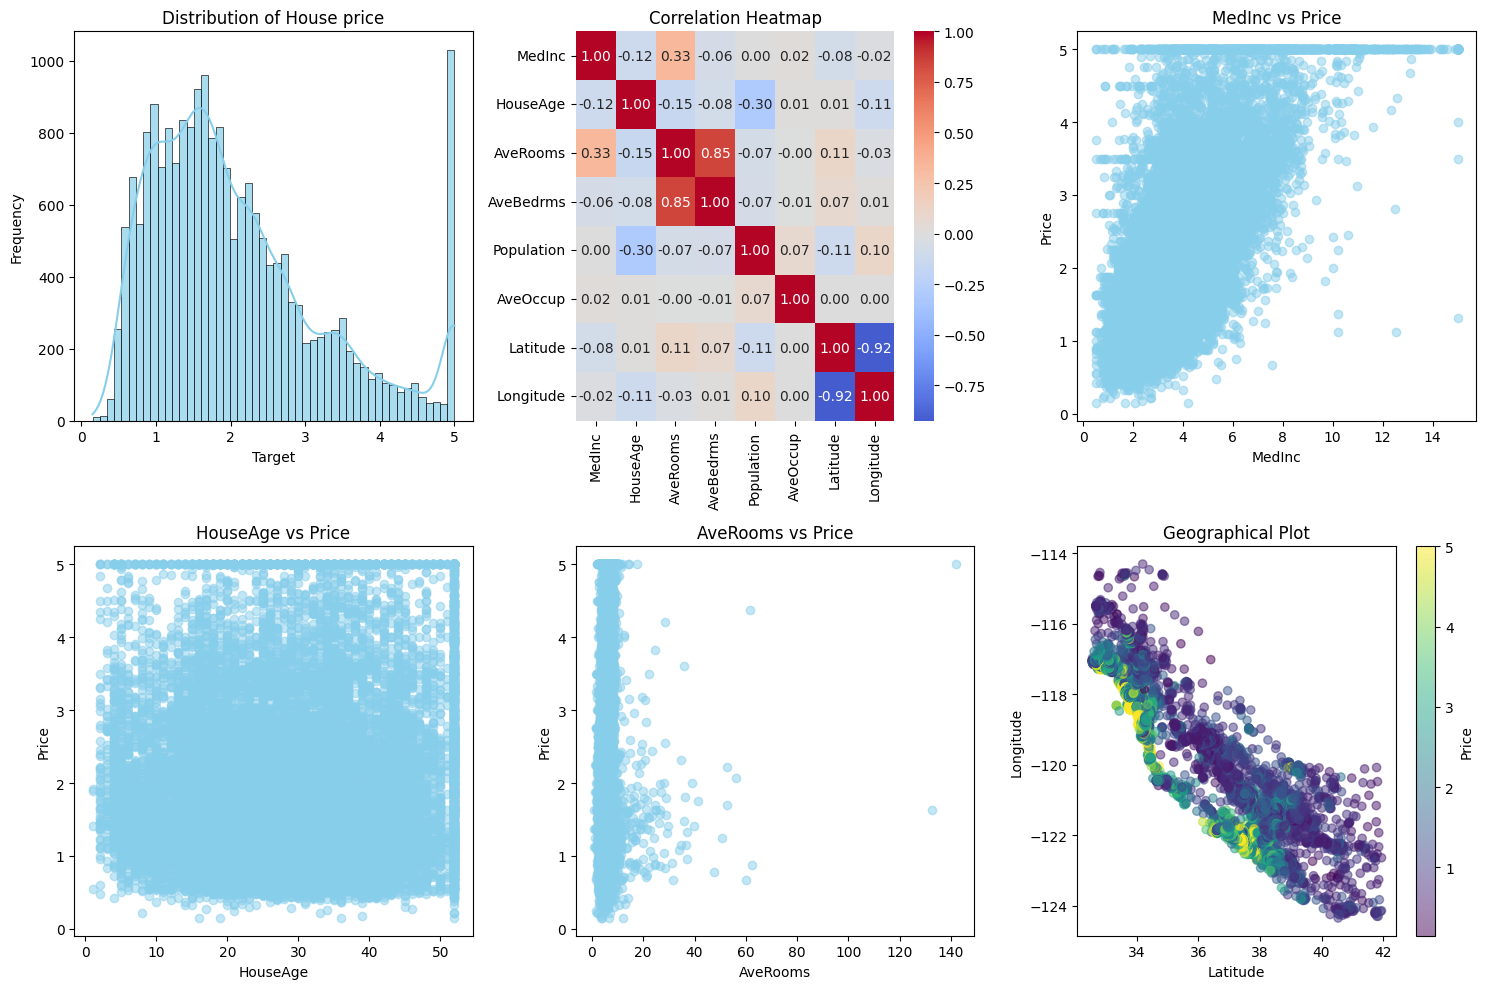

In [8]:
# Creating Visulization
plt.figure(figsize=(15,10))

# Distribution of Target variable
plt.subplot(2,3,1)
sns.histplot(y, bins=50, kde=True, alpha=0.7, color='skyblue')
plt.title('Distribution of House price')
plt.xlabel('Target')
plt.ylabel('Frequency')

# # Correlation heatmap
plt.subplot(2,3,2)
corr_matirx = x.corr()
sns.heatmap(corr_matirx, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')

# Scatter plot Medinc & Price
plt.subplot(2,3,3)
plt.scatter(x['MedInc'], y, alpha=0.5, color='skyblue')
plt.title('MedInc vs Price')
plt.xlabel('MedInc')
plt.ylabel('Price')

# Scatter plot Houseage & price
plt.subplot(2,3,4)
plt.scatter(x['HouseAge'], y, alpha=0.5, color='skyblue')
plt.title('HouseAge vs Price')
plt.xlabel('HouseAge')
plt.ylabel('Price')

# Scatterplot Averoom & Price
plt.subplot(2,3,5)
plt.scatter(x['AveRooms'], y, alpha=0.5, color='skyblue')
plt.title('AveRooms vs Price')
plt.xlabel('AveRooms')
plt.ylabel('Price')

# Geographical plot
plt.subplot(2,3,6)
plt.scatter(x['Latitude'], x['Longitude'], c=y, alpha=0.5)
plt.colorbar(label='Price')
plt.title('Geographical Plot')
plt.xlabel('Latitude')
plt.ylabel('Longitude')

plt.tight_layout()
plt.show()

# Data Preprocessing and Cleaning

In [9]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True)

print('Data Split Complete')
print(f'X_train shape : {X_train.shape}')
print(f'X_test shape : {X_test.shape}')
print(f'Y_train shape : {y_train.shape}')
print(f'Y_test shape : {y_test.shape}')

print(f'\nTraining set: {len(X_train)} samples ({len(X_train)/len(x)*100:.1f}%)')
print(f'Testing set: {len(X_test)} samples ({len(X_test)/len(x)*100:.1f}%)')


Data Split Complete
X_train shape : (16512, 8)
X_test shape : (4128, 8)
Y_train shape : (16512,)
Y_test shape : (4128,)

Training set: 16512 samples (80.0%)
Testing set: 4128 samples (20.0%)


In [10]:
# Scale the feature using Standardscaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Compelted")
print('\nOriginal X_train')
print(f'mean {X_train.mean().mean():.3f}') # one mean is used for every colum individual mean (and second mean calculate the all individal mean into the single mean)
print(f'std {X_train.std().mean():.3f}') # same ase first find the every col std and then every std value for col combine the mean single value

print('\nScaled X_train')
print(f'mean {X_train_scaled.mean():.3f}')
print(f'std {X_train_scaled.std():.3f}')

print('\n First 5 Row of Scaled X_train')
print(X_train_scaled[:5])

Feature Scaling Compelted

Original X_train
mean 173.079
std 146.263

Scaled X_train
mean 0.000
std 1.000

 First 5 Row of Scaled X_train
[[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
  -1.3728112   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 -0.12853018 -0.09890135 -0.11736222
  -0.87669601  0.70916212]
 [ 0.14470145 -1.95271028  0.08821601 -0.25753771 -0.44981806 -0.03227969
  -0.46014647 -0.44760309]
 [-1.01786438  0.58654547 -0.60001532 -0.14515634 -0.00743434  0.07750687
  -1.38217186  1.23269811]
 [-0.17148831  1.14200767  0.3490073   0.08662432 -0.48587717 -0.06883176
   0.5320839  -0.10855122]]


# Model Training

In [11]:
model = LinearRegression()

print('Training the Linear Regression model')
model.fit(X_train_scaled, y_train)

Training the Linear Regression model


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
print('Model Training Complete')
print(f'Model Coefficient : {model.coef_}')
print(f'Model Intercept : {model.intercept_}')

Model Training Complete
Model Coefficient : [ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]
Model Intercept : 2.071946937378881


# Model Evaluation

In [13]:
# Make Prediction on both training and testing
y_train_pred = model.predict(X_train_scaled) # Predicts on the training set to check how well the model learned from the data it was trained on.
y_test_pred = model.predict(X_test_scaled) # Predicts on the test set to check how well the model generalizes to unseen data.

# Calculate evaluation metrics
print('Mean Squared Error (MSE)', mean_squared_error(y_train, y_train_pred))
print('Mean Squared Error (MSE)', mean_squared_error(y_test, y_test_pred))
print('....'*30)

print('Root Mean Squared Error (RMSE)', np.sqrt(mean_squared_error(y_train, y_train_pred)))
print('Root Mean Squared Error (RMSE)', np.sqrt(mean_squared_error(y_test, y_test_pred)))
print('....'*30)

print('R2 score', r2_score(y_train, y_train_pred))
print('R2 score', r2_score(y_test, y_test_pred))


Mean Squared Error (MSE) 0.5179331255246699
Mean Squared Error (MSE) 0.5558915986952444
........................................................................................................................
Root Mean Squared Error (RMSE) 0.7196757085831575
Root Mean Squared Error (RMSE) 0.7455813830127764
........................................................................................................................
R2 score 0.6125511913966952
R2 score 0.5757877060324508


In [14]:
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print('Model Evaluation Result')
print('='*20)
print('Training Set')
print(f'Mean Squrea error (MSE): {train_mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {np.sqrt(train_mse):.2f}')
print(f'R2 Score: {train_r2:.2}')

print('\nTesting Set')
print(f'Mean Squrea error (MSE): {test_mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {np.sqrt(test_mse):.2f}')
print(f'R2 Score: {test_r2:.2}')

print('\nModel Performance summary')
print(f'the model explain: {test_r2*100:.2f}% of the variance in the target variable')
print(f'Average prediction error: ${np.sqrt(test_mse)*100:.2f}K')


Model Evaluation Result
Training Set
Mean Squrea error (MSE): 0.52
Root Mean Squared Error (RMSE): 0.72
R2 Score: 0.61

Testing Set
Mean Squrea error (MSE): 0.56
Root Mean Squared Error (RMSE): 0.75
R2 Score: 0.58

Model Performance summary
the model explain: 57.58% of the variance in the target variable
Average prediction error: $74.56K


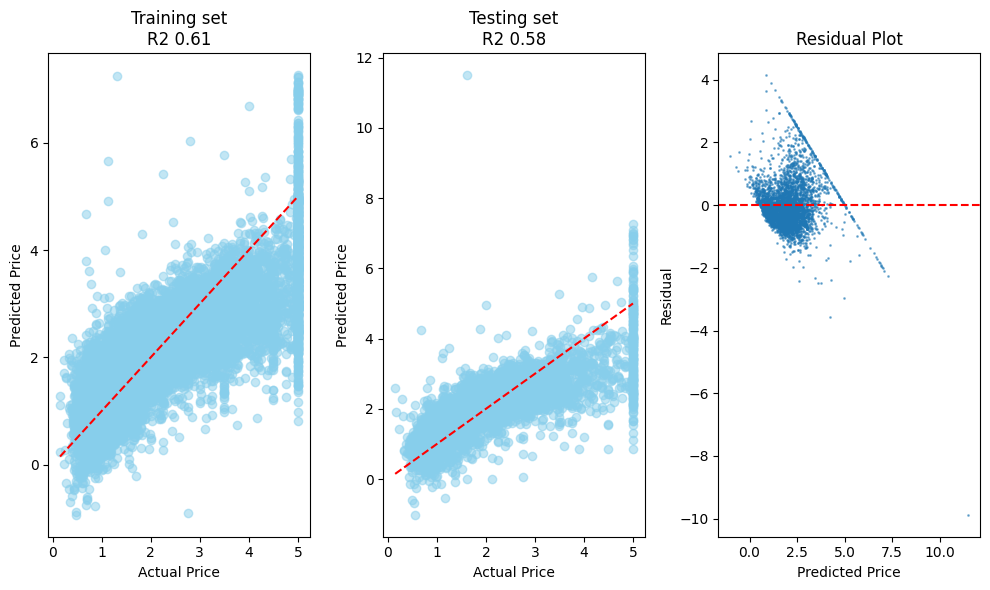

In [15]:
 # Visulize predicted and actual values
plt.figure(figsize=(10,6))

# Training set
plt.subplot(1,3,1)
plt.scatter(y_train, y_train_pred, alpha=0.5, color='skyblue')
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], linestyle='--', color='red')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Training set\nR2 {train_r2:.2f}')

# Testing set
plt.subplot(1,3,2)
plt.scatter(y_test, y_test_pred, alpha=0.5, color='skyblue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Testing set\nR2 {test_r2:.2f}')

plt.subplot(1,3,3)
residual = y_test- y_test_pred
plt.scatter(y_test_pred, residual, alpha=0.5, s=1)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residual')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()

# Model Saving

In [16]:
import pickle
# Save the training model using pkl
model_filename = 'Linear_Regression_model.pkl'

with open(model_filename, 'wb') as file:
  pickle.dump(model, file)

print(f'Training model save to {model_filename}')

# Save the scaler as well(very important for deployment)
scaler_filename = 'scaler.pkl'
with open(scaler_filename, 'wb') as file:
  pickle.dump(scaler, file)

print(f'Scaler save to {scaler_filename}')

# Verify that we can load the model back
print('\nVerifying saved files ....')
with open(model_filename, 'rb') as file:
  loaded_model = pickle.load(file)

with open(scaler_filename, 'rb') as file:
  loaded_scaled = pickle.load(file)

print('\nModel and Scaler loaded successfully for Verifications')

sample_prediction = loaded_model.predict(X_train_scaled[:1])
print(f'Sample prediction with loaded model ${sample_prediction[0]*100:.0f}K')
print(f'Actual value for sample ${y_test.iloc[0]*100:.0f}K')
print(f'Predictin error ${abs(sample_prediction[0] - y_test.iloc[0])*100:.0f}K')

Training model save to Linear_Regression_model.pkl
Scaler save to scaler.pkl

Verifying saved files ....

Model and Scaler loaded successfully for Verifications
Sample prediction with loaded model $194K
Actual value for sample $48K
Predictin error $146K
